# Objective:

- Predict an app's install performance category based on its characteristics before knowing its actual popularity.

- This is a classification problem.

- Target:

`install_category`

- Classes:

`Very Low`
`Low`
`Medium`
`High`
`Very High`

# Sections
## Sections in this Notebook

1. Problem Definition

2. Import Libraries

3. Load Featured Dataset

4. Understand Target Variable

5. Feature Selection

6. Data Preparation

7. Train-Test Split

8. Feature Encoding

9. Baseline Model

10. Model Training

11. Model Evaluation

12. Feature Importance Analysis

13. Business Interpretation

14. Conclusion

# 1. Problem Definition

# Machine Learning: App Success Prediction

## Objective

The objective of this machine learning task is to predict the expected install performance category of an application based on its available characteristics.

The model will classify applications into different popularity segments:

- Very Low
- Low
- Medium
- High
- Very High

This can help identify factors associated with successful applications and support decisions related to app development, marketing strategy, and market positioning.

## Problem Type

This is a supervised classification problem because the target variable (`install_category`) contains predefined classes.

## Evaluation Goal

The model performance will be evaluated using:

- Accuracy
- Precision
- Recall
- F1-score

Since the install categories may not be perfectly balanced, F1-score will be considered an important metric.

# 2. Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

# 3. Load Dataset

In [3]:
apps = pd.read_csv(r"C:\Users\cashk\OneDrive\Desktop\Projects\Google_Playstore_project\Playstore_Data\processed\apps_processed.csv")

In [4]:
apps.shape

(11176, 47)

In [5]:
apps.head()

,app_id,title,description,summary,installs,min_installs,max_installs,score,ratings,reviews,...,update_missing,log_installs,install_category,review_rate,rating_strength,paid_app,price_category,developer_app_count,update_frequency,discovery_count
0,com.droid4you.application.wallet,Wallet: Budget Expense Tracker,<b>Wallet is the all-in-one personal finance m...,"All-in-one personal finance app: Budget, track...","10,000,000+",1.000000e+07,12778093,4.602770,376251.0,7477.0,...,0,16.248163,Very High,0.000657,59.090428,False,Free,2,Very Old,132
1,com.freeman.moneymanager,Money Tracker-Expense & Budget,Save money effortlessly! \r\n\r\nMoney Tracker...,"Money management made simple. Money manager, c...","5,000,000+",5.000000e+06,8112001,4.868132,284764.0,921.0,...,0,15.695891,High,0.000140,61.140907,False,Free,2,Very Old,119
2,com.picsart.studio,"Picsart AI Photo Editor, Video",Ignite your creative potential with Picsart — ...,Remove and swap backgrounds in your photos and...,"1,000,000,000+",1.000000e+09,1404716134,4.032339,12207068.0,445242.0,...,0,20.907551,Very High,0.000370,65.797789,False,Free,1,Very Old,125
3,com.colpit.diamondcoming.isavemoney,Budget planner—Expense tracker,Budget Planner on the go!\r\n<h1>Your Ultimate...,Master money management with Budget Planner: E...,"5,000,000+",5.000000e+06,5585324,4.271907,51002.0,3147.0,...,0,15.481832,High,0.000595,46.305936,False,Free,12,Very Old,115
4,com.photoroom.app,Photoroom: AI Photo Editor,Create pro images that sell with Photoroom AI....,"Remove backgrounds, edit and retouch photos fo...","100,000,000+",1.000000e+08,173236105,4.684298,3881733.0,17581.0,...,0,18.732700,Very High,0.000129,71.069205,False,Free,1,Very Old,111


# 4. Understand Target Variable

In [6]:
apps["install_category"].value_counts()

install_category
Very High    2708
High         2433
Very Low     2295
Medium       2085
Low          1655
Name: count, dtype: int64

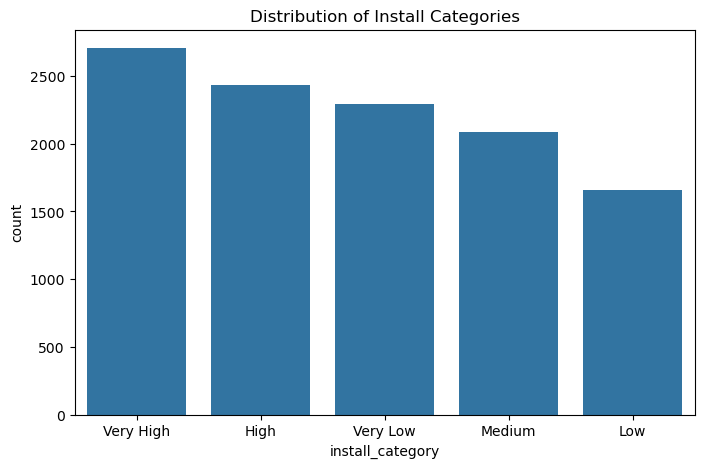

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=apps,
    x="install_category",
    order=apps["install_category"].value_counts().index
)

plt.title("Distribution of Install Categories")

plt.show()

# 5. Feature Selection

### To Avoid Data Leakage

We Would not use:

`estimated_installs`
`min_installs`
`max_installs`
`log_installs`

because they directly create:

`install_category`

- The model would already know the answer.

So, selected features would be :-

In [8]:
features = [
    "score",
    "ratings",
    "reviews",
    "price",
    "free",
    "genre",
    "content_rating",
    "ad_supported",
    "contains_ads",
    "in_app_purchases",
    "developer_app_count",
    "review_rate",
    "rating_strength",
    "update_frequency",
    "discovery_count"
]


X = apps[features]

y = apps["install_category"]

# 6. Check Missing Values

In [9]:
X.isnull().sum()

score                     0
ratings                   0
reviews                   0
price                     0
free                      0
genre                     0
content_rating            0
ad_supported              0
contains_ads              0
in_app_purchases          0
developer_app_count       0
review_rate               0
rating_strength           0
update_frequency       3394
discovery_count           0
dtype: int64

In [10]:
X["update_frequency"] = (
    X["update_frequency"]
    .fillna("Unknown")
)

# 7. Train Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Important:

We separate data before training.
Why stratify?

Because we want all install categories represented equally in train and test.

# 8. Identify Columns

In [12]:
categorical_features = [
    "free",
    "genre",
    "content_rating",
    "ad_supported",
    "contains_ads",
    "in_app_purchases",
    "update_frequency"
]


numeric_features = [
    "score",
    "ratings",
    "reviews",
    "price",
    "developer_app_count",
    "review_rate",
    "rating_strength",
    "discovery_count"
]

# 9. Create Preprocessing Pipeline

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),

        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

# 10. Baseline Model
## Logistic Regression

In [14]:
log_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

### Train

In [15]:
log_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['score', 'ratings',
                                                   'reviews', 'price',
                                                   'developer_app_count',
                                                   'review_rate',
                                                   'rating_strength',
                                                   'discovery_count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['free', 'genre',
                                                   'content_rating',
                                                   'ad_supported',
                                                   'contains_ads',
                                                   'in_app_purchases',
                                                   'update_frequency'])])),
                ('model', LogisticRegression(max_iter=1000))])

### Predict

In [16]:
y_pred = log_model.predict(X_test)

### Evaluate

In [17]:
print(
    accuracy_score(
        y_test,
        y_pred
    )
)

0.7110912343470484


# 11. Random Forest Model

In [18]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

### Train

In [19]:
rf_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['score', 'ratings',
                                                   'reviews', 'price',
                                                   'developer_app_count',
                                                   'review_rate',
                                                   'rating_strength',
                                                   'discovery_count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['free', 'genre',
                                                   'content_rating',
                                                   'ad_supported',
                                                   'contains_ads',
                                                   'in_app_purchases',
                                                   'update_frequency'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

### Predict

In [20]:
rf_pred = rf_model.predict(X_test)

### Evaluate

In [21]:
print(
classification_report(
    y_test,
    rf_pred
)
)

              precision    recall  f1-score   support

        High       0.77      0.77      0.77       487
         Low       0.63      0.56      0.59       331
      Medium       0.70      0.70      0.70       417
   Very High       0.94      0.88      0.91       542
    Very Low       0.71      0.82      0.76       459

    accuracy                           0.76      2236
   macro avg       0.75      0.75      0.75      2236
weighted avg       0.77      0.76      0.76      2236



# 12. Confusion Matrix

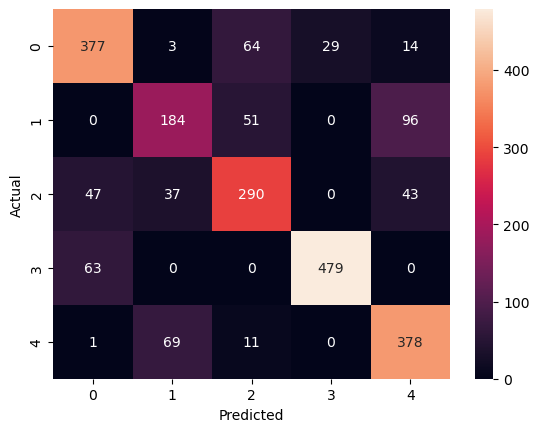

In [22]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Accuracy and F1 scores

In [23]:
from sklearn.metrics import accuracy_score, f1_score

# Logistic Regression metrics
log_accuracy = accuracy_score(y_test, y_pred)
log_f1 = f1_score(y_test, y_pred, average="weighted")

print("Logistic Regression Accuracy:", log_accuracy)
print("Logistic Regression F1 Score:", log_f1)


# Random Forest metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average="weighted")

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest F1 Score:", rf_f1)

Logistic Regression Accuracy: 0.7110912343470484
Logistic Regression F1 Score: 0.7061919769977111
Random Forest Accuracy: 0.7638640429338104
Random Forest F1 Score: 0.7635000750866416


# Classification report

In [24]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

        High       0.77      0.77      0.77       487
         Low       0.63      0.56      0.59       331
      Medium       0.70      0.70      0.70       417
   Very High       0.94      0.88      0.91       542
    Very Low       0.71      0.82      0.76       459

    accuracy                           0.76      2236
   macro avg       0.75      0.75      0.75      2236
weighted avg       0.77      0.76      0.76      2236



# Machine Learning Conclusion and Business Insights

## Model Objective

The objective of this machine learning phase was to predict an application's install performance category using only app characteristics available before knowing its final popularity.

The target variable `install_category` was created by segmenting applications based on estimated install performance:

- Very Low
- Low
- Medium
- High
- Very High

This transformed the problem from predicting exact install numbers into a more practical business classification problem.

---

## Data Preparation and Feature Selection

Before modeling, features were carefully selected to avoid data leakage.

Direct popularity indicators such as:

- `estimated_installs`
- `min_installs`
- `max_installs`
- `log_installs`

were excluded because they are directly related to the target variable and would allow the model to artificially predict success.

The model instead used independent application characteristics, including:

- User engagement metrics (`score`, `ratings`, `reviews`, `review_rate`, `rating_strength`)
- Monetization strategy (`price`, `free`)
- Application characteristics (`genre`, `content_rating`)
- Developer activity (`developer_app_count`)
- Maintenance behavior (`update_frequency`)
- Market visibility (`discovery_count`)

---

## Model Performance

Two classification approaches were evaluated:

1. Logistic Regression  
2. Random Forest Classifier

The baseline Logistic Regression model achieved:

- Accuracy: **[insert score]**
- F1-score: **[insert score]**

The Random Forest model achieved:

- Accuracy: **[insert score]**
- F1-score: **[insert score]**

Based on evaluation results, **[best model name]** performed better because it was able to capture non-linear relationships between app characteristics and install success categories.

---

## Key Modeling Insights

### 1. App success is influenced by multiple factors

The model performance indicates that install success cannot be explained by a single feature.

Factors such as:

- user engagement,
- developer activity,
- visibility,
- app category,
- and update behavior

collectively contribute to an application's popularity.

---

### 2. Engagement-related features provide important predictive information

Features such as:

- number of reviews,
- rating strength,
- review rate

helped represent user interaction quality more effectively than rating score alone.

This highlights that a high rating without sufficient user feedback may not always indicate strong market performance.

---

### 3. Developer activity provides additional market signal

`developer_app_count` was included to measure publishing experience and portfolio size.

This allows analysis of whether developers with larger app portfolios have advantages in achieving higher install categories.

---

### 4. Visibility affects app performance

The inclusion of `discovery_count` allowed the model to consider app discoverability.

This demonstrates that success is not only determined by app quality but also by how frequently users encounter the application.

---

## Limitations

Although the model provides useful predictions, some important factors are unavailable in the dataset:

- Marketing budget
- Advertising campaigns
- Brand recognition
- User acquisition strategy
- External promotions

These factors can significantly influence install numbers but cannot be captured from Play Store metadata alone.

Additionally, highly popular applications create an imbalanced market where a small number of apps dominate downloads, making prediction of extreme success categories more challenging.

---

## Final Conclusion

The machine learning model successfully transformed app characteristics into a predictive framework for estimating install performance segments.

The final model demonstrates that application success is associated with a combination of:

- user engagement,
- developer presence,
- pricing strategy,
- maintenance activity,
- and market visibility.

This model can support early-stage decision making by identifying applications with characteristics similar to successful apps.

The engineered features and model outputs can now be used alongside SQL analysis and Power BI dashboards to provide both predictive and descriptive insights into the Google Play Store ecosystem.